<a href="https://colab.research.google.com/github/giumont/overlap_resolver/blob/main/notebooks/DNN_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT FILE DATI DA GOOGLE

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# IMPORT GITHUB REPO: flavour_tag_ml (repo "flavour_tagging")

from google.colab import userdata
import os
import sys

token = userdata.get("GITHUB_TOKEN")

REPO_PATH_FLAVOUR_TAG_ML = "/content/flavour_tagging"

if not os.path.exists(REPO_PATH_FLAVOUR_TAG_ML):
    !git clone https://{token}@github.com/giumont/flavour_tagging.git {REPO_PATH_FLAVOUR_TAG_ML}
else:
    !git -C {REPO_PATH_FLAVOUR_TAG_ML} pull --rebase

# The importable package lives under <repo>/src/flavour_tag_ml, so we add
# <repo>/src (not the repo root) to sys.path and import it as a top-level
# package: "import flavour_tag_ml".
SRC_PATH_FLAVOUR_TAG_ML = os.path.join(REPO_PATH_FLAVOUR_TAG_ML, "src")
if SRC_PATH_FLAVOUR_TAG_ML not in sys.path:
    sys.path.append(SRC_PATH_FLAVOUR_TAG_ML)

import flavour_tag_ml


Cloning into '/content/flavour_tagging'...
remote: Enumerating objects: 905, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 905 (delta 40), reused 47 (delta 18), pack-reused 815 (from 2)
Receiving objects: 100% (905/905), 156.47 MiB | 19.98 MiB/s, done.
Resolving deltas: 100% (475/475), done.


In [3]:
# IMPORT GITHUB REPO: overlap_resolver
#
# Contains, under "src/": obj_3_1.py, overlap_kinematics.py,
# truth_vs_reco_params.py and overlap_pairs_dataset_builder.py (this
# notebook's main orchestrator).

token_overlap = userdata.get("GITHUB_TOKEN_OVERLAP_RESOLVER")

REPO_PATH_OVERLAP_RESOLVER = "/content/overlap_resolver"

if not os.path.exists(REPO_PATH_OVERLAP_RESOLVER):
    !git clone https://{token_overlap}@github.com/giumont/overlap_resolver.git {REPO_PATH_OVERLAP_RESOLVER}
else:
    !git -C {REPO_PATH_OVERLAP_RESOLVER} pull --rebase

# Unlike flavour_tag_ml, the modules under overlap_resolver/src are FLAT:
# they import each other directly (e.g. overlap_kinematics.py does
# "from obj_3_1 import ..." and "from truth_vs_reco_params import ...",
# NOT "from src.obj_3_1 import ..."). To keep them working unmodified, we
# append the "src" folder ITSELF to sys.path (not the repo root), and
# import them below as flat top-level modules.
SRC_PATH_OVERLAP_RESOLVER = os.path.join(REPO_PATH_OVERLAP_RESOLVER, "src")
if SRC_PATH_OVERLAP_RESOLVER not in sys.path:
    sys.path.append(SRC_PATH_OVERLAP_RESOLVER)


Cloning into '/content/overlap_resolver'...
remote: Enumerating objects: 353, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 353 (delta 37), reused 32 (delta 17), pack-reused 291 (from 1)
Receiving objects: 100% (353/353), 657.14 MiB | 23.87 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Updating files: 100% (262/262), done.


In [4]:
# IMPORT FILE PROGETTO DA GITHUB

from flavour_tag_ml.data import JetDataset, build_jet_features, extract_balanced_subset, compute_feature_stats
from flavour_tag_ml.merge_datasets import merge_checkpoint_chunks, check_checkpoint_progress

from flavour_tag_ml.models import create_model
from flavour_tag_ml.training import run_epoch, get_predictions, train_model

from flavour_tag_ml.utils import set_seed, load_mmap, save_run_outputs, build_metrics_report, run_evaluation_suite

In [6]:
# To reload imported files if they have been modified during runtime

import importlib
import flavour_tag_ml.data
import flavour_tag_ml.models
import flavour_tag_ml.training

importlib.reload(flavour_tag_ml.data)
importlib.reload(flavour_tag_ml.merge_datasets)
importlib.reload(flavour_tag_ml.models)
importlib.reload(flavour_tag_ml.training)

#from flavour_tag_ml.utils import build_jet_features

<module 'flavour_tag_ml.training' from '/content/flavour_tagging/src/flavour_tag_ml/training.py'>

In [5]:
# IMPORT PYTHON LIBRARIES

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# sposta file in memoria locale colab
#!cp /content/drive/MyDrive/obj_2/*.h5 /content/

In [6]:
#################################################################
# GLOBAL PARAMS
#################################################################

# FILES
#DATASETS_DIR = '/content/' #gpu
INPUT_DIR = "/content/drive/MyDrive/overlap_resolver/datas/np_arrays/HH_bbtt" #cpu

TRAINSET_X_NAME = 'X_train_normalized.npy'
TRAINSET_Y_NAME = 'y_train_normalized.npy'

VALSET_X_NAME   = 'X_val_normalized.npy'
VALSET_Y_NAME   = 'y_val_normalized.npy'

TESTSET_X_NAME  = 'X_test_normalized.npy'
TESTSET_Y_NAME = 'y_test_normalized.npy'

#CHECK_LOAD_FILENAME = 'train_normalization_params.npz' # file with weights and feature_names (available for full, not reduced dataset)
CHECK_LOAD_FILENAME = "pair_feature_names.npz"

# DATASET
N_TRAIN = None
N_VAL   = None
N_TEST  = None

# OUTPUT_DIR = '/content/drive/MyDrive/flavour_tagging/obj_2/datas/np_arrays/MC23G_dataset'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_DIR = None

SUB_TRAINSET_NAME = None
SUB_VALSET_NAME = None
SUB_TESTSET_NAME = None

# PROBLEM DEFINITION
NUM_CLASSES = 4 # FF=0, FT=1, TF=2, TT=3
CLASS_NAMES = ["FF", "FT", "TF", "TT"]  # ordine coerente con le label 0,1,2,3

TASK = "multiclass" if NUM_CLASSES > 2 else "binary"

# RETE
HIDDEN_DIMS = (32, 16)

ACTIV_FUNC = nn.ReLU()
NORM_LAYER = nn.LayerNorm

DROPOUT = 0.1 # percentuale neuroni disattivati randomicamente: riduce overfitting

MODEL_CONFIG = {
    "name": "MLPMultiTagger",
    "hidden_dims": HIDDEN_DIMS,
    "num_classes": NUM_CLASSES,
    "norm_layer": NORM_LAYER,
    "dropout": DROPOUT,
}

# TRAINING
BEST_MODEL_FOR_VALIDATION = True # False: salva a prescindere i weights dell'ultima epoca; True: previene overfitting
BEST_MODEL_METRIC = "ap_macro" # "mean" / "median" / "f1_macro" / "ap_macro": quale metrica su val viene considerata per aggiornare best_model

CRITERION = nn.CrossEntropyLoss
WEIGHTED_LOSS = True

LR = 1e-3 # learning rate ottimizzatore
WEIGHT_DECAY = 1e-4  # regolarizzazione L2 nell'ottimizzatore

OPTIMIZER_CONFIG = {
    "name": "AdamW",
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
}

SCHEDULER_FACTOR = 0.7
SCHEDULER_PATIENCE = 5

SCHEDULER_CONFIG = {
    "name": "ReduceLROnPlateau",
    "factor": SCHEDULER_FACTOR,
    "patience": SCHEDULER_PATIENCE,
    "mode": "max"   # "max" must be used with "f1_macro" / "ap_macro" metrics
}

BATCH_SIZE = 2048
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

MIN_DELTA_VAL_LOSS = 1e-4 # soglia minima miglioramento loss su valset tra due epoche

# PARAMETRI DI RETE / TRAINING DA ANNOTARE SUI GRAFICI
PLOT_PARAMS = {
    "hidden_dims": HIDDEN_DIMS,
    "norm_layer": NORM_LAYER.__name__,
    "activation": ACTIV_FUNC.__class__.__name__,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
}

# Suffisso comune per i nomi dei file salvati (architettura + training)
RUN_TAG = (
    f"{len(HIDDEN_DIMS)}layers_"
    f"{'_'.join(str(h) for h in HIDDEN_DIMS)}_"
    f"dropout{DROPOUT}_{NORM_LAYER.__name__}_batch{BATCH_SIZE}"
    f"_lr{LR}_wd{WEIGHT_DECAY}"
    f"best_on_{BEST_MODEL_METRIC}"
    f"criterion_{CRITERION}"
    f"weight_loss=={WEIGHTED_LOSS}"
)

# Store weights: nome/percorso generati automaticamente da RUN_TAG,
MODEL_DIR = '/content/drive/MyDrive/overlap_resolver/models/HH_bbtt_dataset'
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_NAME = f"best_model_{RUN_TAG}.pt"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)

# GRAPHICS
GRAPHICS_DIR = "/content/drive/MyDrive/overlap_resolver/graphics/model_eval/HH_bbtt_dataset"
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# GITHUB
GIT_OUTPUT_DIR = "DNN/HH_bbtt_dataset"

# OTHER
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# SET GLOBAL SEED
set_seed(RANDOM_SEED)

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU: Tesla T4


In [10]:
# LOADING INPUT

X_train = load_mmap(INPUT_DIR, TRAINSET_X_NAME)
y_train = load_mmap(INPUT_DIR, TRAINSET_Y_NAME)

X_val = load_mmap(INPUT_DIR, VALSET_X_NAME)
y_val = load_mmap(INPUT_DIR, VALSET_Y_NAME)

X_test = load_mmap(INPUT_DIR, TESTSET_X_NAME)
y_test = load_mmap(INPUT_DIR, TESTSET_Y_NAME)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(377567, 21) (377567,)
(80923, 21) (80923,)
(81083, 21) (81083,)


In [ ]:
# WEIGHTS PER LOSS PESATA - GESTIONE IMBALANCE CLASSI

if WEIGHTED_LOSS:
  # Class weighting per gestire l'imbalance (FF 10.1%, FT 73.1%, TF 16.1%, TT 0.65%).
  # Calcolati SOLO sul train set (mai su val/test).
  train_class_counts = torch.bincount(torch.as_tensor(y_train, dtype=torch.long), minlength=NUM_CLASSES).float()
  CLASS_WEIGHTS = train_class_counts.sum() / (NUM_CLASSES * train_class_counts)
  CLASS_WEIGHTS = CLASS_WEIGHTS.to(DEVICE)

  CRITERION = CRITERION(weight=CLASS_WEIGHTS)

else:
  CLASS_WEIGHTS = None
  CRITERION = CRITERION(weight=None)

In [11]:
# PARAMETRI DI RETE / TRAINING DA ANNOTARE SUI GRAFICI

PLOT_PARAMS = {
    "n_overlap_couples": int(X_train.shape[0]),
    "n_features": int(X_train.shape[1]),
    "hidden_dims": HIDDEN_DIMS,
    "norm_layer": NORM_LAYER.__name__,
    "activation": ACTIV_FUNC.__class__.__name__,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    #"best_model_metric": BEST_MODEL_METRIC,
    "class_names": CLASS_NAMES,
    "class_weights": CLASS_WEIGHTS
}


In [ ]:
# Extraction of balanced subOUTPUT of required dimensions

X_train, y_train = extract_balanced_subset(X_train, y_train, N_TRAIN, seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_TRAINSET_NAME)
X_val,   y_val   = extract_balanced_subset(X_val,   y_val,   N_VAL,   seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_VALSET_NAME)
X_test,  y_test  = extract_balanced_subset(X_test,  y_test,  N_TEST,  seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_TESTSET_NAME)

print("Train:", X_train.shape, y_train.shape, "| bilanciamento:", y_train.mean())
print("Val:  ", X_val.shape,   y_val.shape,   "| bilanciamento:", y_val.mean())
print("Test: ", X_test.shape,  y_test.shape,  "| bilanciamento:", y_test.mean())

NameError: name 'X_train' is not defined

In [12]:
# # CHECK - VERIFY RELOAD CORRECTNESS

# if CHECK_LOAD_FILENAME is None:
#     print("INFO - CHECK_LOAD_FILENAME non specificato: salto il caricamento dei parametri di normalizzazione e dei nomi features.")
#     mean = std = train_feature_names = None

# else:
#     norm_params_path = os.path.join(INPUT_DIR, CHECK_LOAD_FILENAME)

#     if os.path.exists(norm_params_path):
#         norm_params_npz = np.load(norm_params_path, allow_pickle=True)

#         print(f"Chiavi in {CHECK_LOAD_FILENAME}:", norm_params_npz.files)

#         mean = norm_params_npz['mean']
#         std = norm_params_npz['std']
#         train_feature_names = norm_params_npz['feature_names']

#         print("Mean shape:", mean.shape, "| Std shape:", std.shape)
#         print("N. feature names:", len(train_feature_names))
#         print("Esempio:", train_feature_names[:3])

#     else:
#         print(f"INFO - '{norm_params_path}' non trovato: salto i controlli su mean/std/feature_names salvati.")
#         mean = std = train_feature_names = None


# print("\n=== SHAPES ===")
# print("X_train:", X_train.shape, "| y_train:", y_train.shape)
# print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
# print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)

# # Coerenza numero campioni X <-> y, per ogni split
# assert len(X_train) == len(y_train), "Mismatch train X/y!"
# assert len(X_val) == len(y_val), "Mismatch val X/y!"
# assert len(X_test) == len(y_test), "Mismatch test X/y!"

# # Stessa dimensionalità delle feature in tutti gli split
# n_features = X_train.shape[1]
# assert X_val.shape[1] == n_features, "Val ha un numero di feature diverso dal train!"
# assert X_test.shape[1] == n_features, "Test ha un numero di feature diverso dal train!"

# if train_feature_names is not None:
#     print("\n=== FEATURE NAMES (da train_normalization_params.npz) ===")
#     print("N. nomi:", len(train_feature_names), "| N. colonne X:", n_features)
#     assert len(train_feature_names) == n_features, "feature_names non combacia col numero di colonne!"
#     print("Primi 3:", train_feature_names[:3])
#     print("Ultimi 3:", train_feature_names[-3:])

#     print("\n=== NORMALIZZAZIONE (mean/std salvati) ===")
#     print("Mean shape:", mean.shape, "| Std shape:", std.shape)
#     assert mean.shape[0] == n_features and std.shape[0] == n_features, "mean/std non combaciano col numero di feature!"

# print("\n=== BILANCIAMENTO CLASSI ===")
# print("Train:", y_train.mean())
# print("Val:  ", y_val.mean())
# print("Test: ", y_test.mean())

# print("\n=== NaN / Inf SU CAMPIONE (evita di leggere l'intero memmap da disco) ===")
# sample_size = 200_000
# for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
#     n = min(sample_size, len(arr))
#     idx = np.sort(np.random.choice(len(arr), size=n, replace=False))
#     sample = arr[idx]
#     n_nan = np.isnan(sample).sum()
#     n_inf = np.isinf(sample).sum()
#     print(f"{name} (campione di {n}): NaN={n_nan}, Inf={n_inf}")
#     assert n_nan == 0 and n_inf == 0, f"{name} contiene NaN/Inf nel campione controllato!"

# print("\n=== SINGOLO CAMPIONE (X_train[0], y_train[0]) ===")
# x_sample, y_sample = X_train[0], y_train[0]
# print("Shape singolo campione X:", np.shape(x_sample), "| dtype:", np.asarray(x_sample).dtype)
# print("Shape singolo campione y:", np.shape(y_sample), "| dtype:", np.asarray(y_sample).dtype)

# print("\nTutti i controlli superati (su campionamento per gli split memory-mapped).")

# # Mean and std on datasets
# mean_train, std_train = compute_feature_stats(X_train)
# mean_val,   std_val   = compute_feature_stats(X_val)
# mean_test,  std_test  = compute_feature_stats(X_test)


# print("\n================ NORMALIZATION CHECK ================\n")

# print("TRAIN")
# print(f"  mean range: [{mean_train.min():.6f}, {mean_train.max():.6f}]")
# print(f"  std  range: [{std_train.min():.6f}, {std_train.max():.6f}]")

# print("\nVAL")
# print(f"  mean range: [{mean_val.min():.6f}, {mean_val.max():.6f}]")
# print(f"  std  range: [{std_val.min():.6f}, {std_val.max():.6f}]")

# print("\nTEST")
# print(f"  mean range: [{mean_test.min():.6f}, {mean_test.max():.6f}]")
# print(f"  std  range: [{std_test.min():.6f}, {std_test.max():.6f}]")

Chiavi in pair_feature_names.npz: ['feature_names', 'label_index_map', 'dr_thr']


KeyError: 'mean is not a file in the archive'

In [13]:
# Dataset Pytorch

train_dataset = JetDataset(X_train, y_train, task=TASK)
val_dataset = JetDataset(X_val, y_val, task=TASK)
test_dataset = JetDataset(X_test, y_test, task=TASK)

# Check type is matched with the type of loss function used
assert train_dataset.y.dtype == (torch.long if TASK == "multiclass" else torch.float32)
assert set(torch.unique(train_dataset.y).tolist()) <= set(range(NUM_CLASSES))

/content/flavour_tagging/src/flavour_tag_ml/data.py:47: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  self.X = torch.as_tensor(X, dtype=torch.float32)


In [14]:
# DataLoader pytorch

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


In [15]:
# Modello
model = create_model(MODEL_CONFIG, input_dim=X_train.shape[1])

# Optimizer e scheduler creati internamente da train_model a partire
# dai config dict (OPTIMIZER_CONFIG, SCHEDULER_CONFIG)
model, train_losses, val_losses = train_model(
    train_loader,
    val_loader,
    model,
    optimizer_config=OPTIMIZER_CONFIG,
    scheduler_config=SCHEDULER_CONFIG,
    criterion=CRITERION,
    max_epochs=MAX_EPOCHS,
    min_delta_val_loss=MIN_DELTA_VAL_LOSS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    best_model_for_validation=BEST_MODEL_FOR_VALIDATION,
    model_selection_metric=BEST_MODEL_METRIC,
    model_path=MODEL_PATH,
    device=DEVICE,
    reset_weights=True,
    resume_from_checkpoint=False,
)

INFO - Total number of trainable parameters: 4257
INFO - Model selection metric: 'mean'


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/23 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/5 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.4666 | Val Loss (mean): 0.3917


...

Epoch 14/50 [train]:   0%|          | 0/23 [00:00<?, ?batch/s]

Epoch 14/50 [val]:   0%|          | 0/5 [00:00<?, ?batch/s]

Epoch 14/50 | Train Loss: -2.6538 | Val Loss (mean): -2.7738


Epoch 15/50 [train]:   0%|          | 0/23 [00:00<?, ?batch/s]

KeyboardInterrupt: 

In [ ]:
# import shutil, os, time

# LOCAL_PATH = '/content/local_data'
# os.makedirs(LOCAL_PATH, exist_ok=True)

# files_to_copy = [
#     'X_train_normalized.npy', 'y_train_normalized.npy',
#     'X_val_normalized.npy',   'y_val_normalized.npy',
# ]

# for f in files_to_copy:
#     src = os.path.join(DATASETS_DIR, f)
#     dst = os.path.join(LOCAL_PATH, f)
#     if not os.path.exists(dst):
#         t0 = time.time()
#         shutil.copy(src, dst)
#         print(f"{f}: copiato in {time.time()-t0:.1f}s")
#     else:
#         print(f"{f}: già presente")

In [ ]:
# def load_mmap_local(name):
#     return np.load(os.path.join(LOCAL_PATH, name), mmap_mode='r')

# X_train = load_mmap_local('X_train_normalized.npy')
# y_train = load_mmap_local('y_train_normalized.npy')
# X_val   = load_mmap_local('X_val_normalized.npy')
# y_val   = load_mmap_local('y_val_normalized.npy')

# train_dataset_partial = JetDataset(X_train, y_train)
# val_dataset_partial   = JetDataset(X_val, y_val)

In [ ]:
# import time
# t0 = time.time()
# for i, (xb, yb) in enumerate(train_loader):
#     if i == 50:
#         break
# t1 = time.time()
# print(f"Tempo per 50 step: {t1-t0:.1f}s -> stima per epoca: {(t1-t0)/50 * len(train_loader):.1f}s")

In [ ]:
#################################################################
# VALUTAZIONE MODELLO + SALVATAGGIO OUTPUT (FIGURE + CONFIG + DATI) SULLA REPO GITHUB
#################################################################
ATLAS_STYLE = True                          # oppure False se non hai mplhep installato
BACKGROUND_REJECTION_EFF_RANGE = (0.2, 1.0) # range realistico per il plot principale
WORKING_POINT_TARGETS = (0.70, 0.75, 0.80, 0.85, 0.90, 0.97)

config = {
    "data": {
        "input_dir": INPUT_DIR,
        "trainset_x_name": TRAINSET_X_NAME,
        "trainset_y_name": TRAINSET_Y_NAME,
        "valset_x_name": VALSET_X_NAME,
        "valset_y_name": VALSET_Y_NAME,
        "testset_x_name": TESTSET_X_NAME,
        "testset_y_name": TESTSET_Y_NAME,
        "output_dir": OUTPUT_DIR,
        "n_train": N_TRAIN,
        "n_val": N_VAL,
        "n_test": N_TEST,
        "sub_trainset_name": SUB_TRAINSET_NAME,
        "sub_valset_name": SUB_VALSET_NAME,
        "sub_testset_name": SUB_TESTSET_NAME,
        "n_overlap_couples": int(X_train.shape[0]),
        "n_features": int(X_train.shape[1]),
        "class_names": CLASS_NAMES,
    },
    "model": {
        **MODEL_CONFIG,
        "activ_func": ACTIV_FUNC.__class__.__name__,
    },
    "training": {
        "criterion": CRITERION.__class__.__name__,
        "class_weights": CLASS_WEIGHTS,
        "optimizer": OPTIMIZER_CONFIG,
        "scheduler": SCHEDULER_CONFIG,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "min_delta_val_loss": MIN_DELTA_VAL_LOSS,
        "best_model_for_validation": BEST_MODEL_FOR_VALIDATION,
    },
    "paths": {
        "model_dir": MODEL_DIR,
        "model_name": MODEL_NAME,
        "model_path": MODEL_PATH,
        "graphics_dir": GRAPHICS_DIR,
    },
    "other": {
        "random_seed": RANDOM_SEED,
        "device": str(DEVICE),
        # tracciati per riproducibilita' delle scelte di plotting
        "atlas_style": ATLAS_STYLE,
        "background_rejection_eff_range": BACKGROUND_REJECTION_EFF_RANGE,
        "working_point_targets": WORKING_POINT_TARGETS,
    },
}

In [16]:
eval_result = run_evaluation_suite(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    train_losses=train_losses,
    val_losses=val_losses,
    device=DEVICE,
    config=config,
    params=PLOT_PARAMS,
    run_name=RUN_TAG,
    run_tag=RUN_TAG,
    graphics_dir=GRAPHICS_DIR,
    repo_path=repo_path,
    output_subdir=GIT_OUTPUT_DIR,
    class_names=CLASS_NAMES
    working_point_targets=WORKING_POINT_TARGETS,
    atlas_style=ATLAS_STYLE,
    background_rejection_eff_range=BACKGROUND_REJECTION_EFF_RANGE,
)

result = eval_result["push_result"]

NameError: name 'train_losses' is not defined

In [ ]:
# INDAGINE: STUDIO DELLA LOSS SUI SINGOLI JET E CONFRONTO CON MEDIA: "LA LOSS E' EFFETTIVAMENTE UN BUON INDICATORE DELLA QUALITA' DEL TRAINING?"


import torch
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from flavour_tag_ml.models import create_model
from flavour_tag_ml.training import get_predictions

MODEL_PATH = os.path.join(MODEL_DIR, f"best_model_3layers_64_32_16_dropout0.3_BatchNorm1d_batch16384.pt")

# 1) Ricostruisci l'architettura ESATTA della run che vuoi ispezionare
#    (deve combaciare col MODEL_CONFIG usato in quella run specifica)
model_to_check = create_model(MODEL_CONFIG, input_dim=X_val.shape[1])
model_to_check.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model_to_check.to(DEVICE)

# 2) Inferenza su val_loader (shuffle=False -> l'ordine dei risultati
#    corrisponde riga per riga a X_val, utile per il punto 4)
val_labels, val_scores, val_logits = get_predictions(model_to_check, val_loader, device=DEVICE)

# 3) Loss per singolo jet — uso i logit (via BCEWithLogitsLoss non ridotta),
#    non log(score) manuale: è la formulazione numericamente stabile,
#    importante proprio se il sospetto è che ci siano logit estremi
logits_t = torch.from_numpy(val_logits)
labels_t = torch.from_numpy(val_labels)
per_sample_loss_val = F.binary_cross_entropy_with_logits(
    logits_t, labels_t, reduction="none"
).numpy()

print("Mean loss (deve combaciare col best_val_loss salvato):", per_sample_loss_val.mean())
print("Median loss:", np.median(per_sample_loss_val))
for p in [50, 90, 95, 99, 99.9, 99.99]:
    print(f"Percentile {p}: {np.percentile(per_sample_loss_val, p):.4f}")
print("Max loss:", per_sample_loss_val.max())
print("AUC:", roc_auc_score(val_labels, val_scores))

# 4) I jet con loss più alta: guarda se hanno feature fuori scala
top_idx = np.argsort(per_sample_loss_val)[-20:]
print(X_val[top_idx])  # valori standardizzati; confronta con le feature che sai avere std residua > 1

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Mean loss (deve combaciare col best_val_loss salvato): 0.48933816
Median loss: 0.26862735
Percentile 50: 0.2686
Percentile 90: 1.2890
Percentile 95: 1.6411
Percentile 99: 2.3705
Percentile 99.9: 3.8304
Percentile 99.99: 4.4055
Max loss: 5.582296
AUC: 0.8472016821703342
[[ 2.43682880e-02 -2.25463867e-01 -2.20703125e-01 ... -1.01658471e-09
   4.53703242e-10  1.15295676e-10]
 [ 1.16333008e-01  2.01171875e-01 -1.16088867e-01 ... -1.01658471e-09
   4.53703242e-10  1.15295676e-10]
 [ 8.81347656e-02 -1.74316406e-01  1.10168457e-01 ... -1.01658471e-09
   4.53703242e-10  1.15295676e-10]
 ...
 [ 1.13647461e-01  2.97119141e-01  1.36108398e-01 ... -1.01658471e-09
   4.53703242e-10  1.15295676e-10]
 [ 2.18139648e-01  3.79150391e-01  1.19238281e+00 ... -1.95045563e-04
   3.08682829e-05 -4.00186400e-05]
 [ 2.31475849e-02 -1.68334961e-01  7.40234375e-01 ... -1.01658471e-09
   4.53703242e-10  1.15295676e-10]]


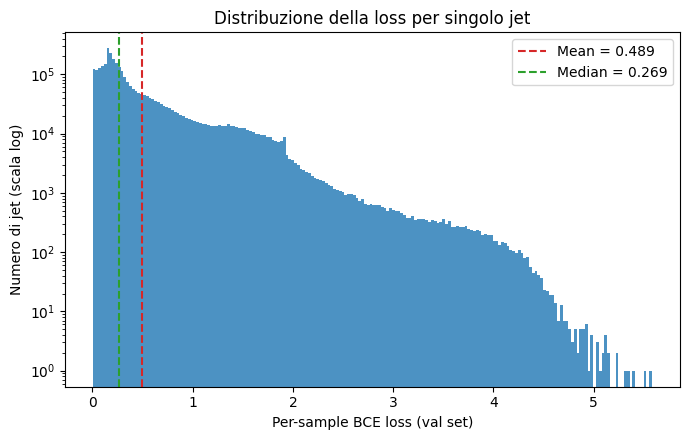

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(per_sample_loss_val, bins=200, log=True, color="tab:blue", alpha=0.8)
ax.axvline(per_sample_loss_val.mean(), color="tab:red", linestyle="--",
           label=f"Mean = {per_sample_loss_val.mean():.3f}")
ax.axvline(np.median(per_sample_loss_val), color="tab:green", linestyle="--",
           label=f"Median = {np.median(per_sample_loss_val):.3f}")
ax.set_xlabel("Per-sample BCE loss (val set)")
ax.set_ylabel("Numero di jet (scala log)")
ax.set_title("Distribuzione della loss per singolo jet")
ax.legend()
plt.tight_layout()
# plt.savefig("loss_distribution.png", dpi=150)

In [ ]:
# INDAGINE: STUDIO DELLA LOSS SUI SINGOLI JET E CONFRONTO CON MEDIA: "LA LOSS E' EFFETTIVAMENTE UN BUON INDICATORE DELLA QUALITA' DEL TRAINING?"


# 1) Ricostruisci l'architettura ESATTA della run che vuoi ispezionare
#    (deve combaciare col MODEL_CONFIG usato in quella run specifica)
model_to_check = create_model(MODEL_CONFIG, input_dim=X_train.shape[1])
model_to_check.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model_to_check.to(DEVICE)

# 2) Inferenza su train_loader (shuffle=False -> l'ordine dei risultati
#    corrisponde riga per riga a X_train, utile per il punto 4)
train_labels, train_scores, train_logits = get_predictions(model_to_check, train_loader, device=DEVICE)

# 3) Loss per singolo jet — uso i logit (via BCEWithLogitsLoss non ridotta),
#    non log(score) manuale: è la formulazione numericamente stabile,
#    importante proprio se il sospetto è che ci siano logit estremi
logits_t = torch.from_numpy(train_logits)
labels_t = torch.from_numpy(train_labels)
per_sample_loss = F.binary_cross_entropy_with_logits(
    logits_t, labels_t, reduction="none"
).numpy()

print("Mean loss (deve combaciare col best_train_loss salvato):", per_sample_loss.mean())
print("Median loss:", np.median(per_sample_loss))
for p in [50, 90, 95, 99, 99.9, 99.99]:
    print(f"Percentile {p}: {np.percentile(per_sample_loss, p):.4f}")
print("Max loss:", per_sample_loss.max())
print("AUC:", roc_auc_score(train_labels, train_scores))

# 4) I jet con loss più alta: guarda se hanno feature fuori scala
top_idx = np.argsort(per_sample_loss)[-20:]
print(X_train[top_idx])  # trainori standardizzati; confronta con le feature che sai avere std residua > 1

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Mean loss (deve combaciare col best_train_loss salvato): 0.37025073
Median loss: 0.18329164
Percentile 50: 0.1833
Percentile 90: 1.0522
Percentile 95: 1.5127
Percentile 99: 2.1988
Percentile 99.9: 3.2574
Percentile 99.99: 4.6560
Max loss: 8.573427
AUC: 0.9114679727606994
[[ 8.9180881e-01 -9.1612250e-01 -6.8491572e-01 ... -8.4736600e-04
  -2.4064448e-04  5.0181101e-05]
 [ 3.4432979e+00 -2.2989457e+00  5.9249908e-01 ... -8.4736600e-04
  -2.4064448e-04  5.0181101e-05]
 [-7.6372695e-01  1.0238549e+00 -1.0524831e+00 ... -8.4736600e-04
  -2.4064448e-04  5.0181101e-05]
 ...
 [-2.1432495e-01  7.6108968e-01  2.5786296e-01 ... -8.4736600e-04
  -2.4064448e-04  5.0181101e-05]
 [ 1.5148844e-01 -1.0446848e-01 -2.9668769e-02 ... -8.4736600e-04
  -2.4064448e-04  5.0181101e-05]
 [ 4.4690067e-01 -1.5671964e-01  1.9278933e-01 ... -8.4736600e-04
  -2.4064448e-04  5.0181101e-05]]


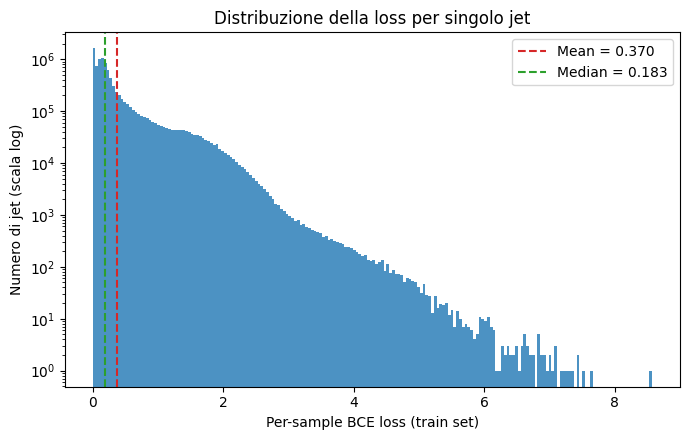

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(per_sample_loss, bins=200, log=True, color="tab:blue", alpha=0.8)
ax.axvline(per_sample_loss.mean(), color="tab:red", linestyle="--",
           label=f"Mean = {per_sample_loss.mean():.3f}")
ax.axvline(np.median(per_sample_loss), color="tab:green", linestyle="--",
           label=f"Median = {np.median(per_sample_loss):.3f}")
ax.set_xlabel("Per-sample BCE loss (train set)")
ax.set_ylabel("Numero di jet (scala log)")
ax.set_title("Distribuzione della loss per singolo jet")
ax.legend()
plt.tight_layout()

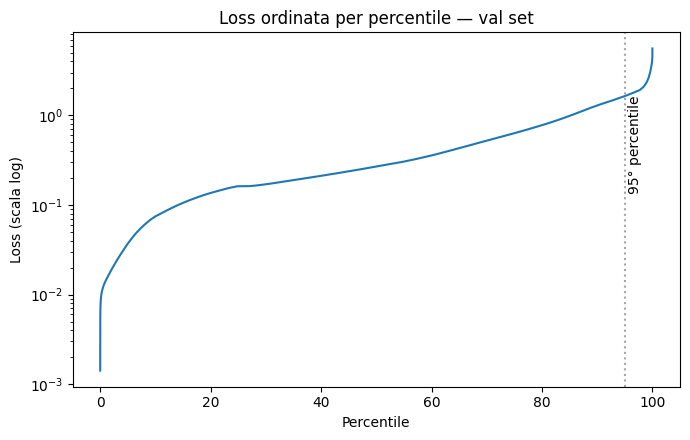

In [ ]:
sorted_loss = np.sort(per_sample_loss)
percentiles = np.linspace(0, 100, len(sorted_loss))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(percentiles, sorted_loss)
ax.set_yscale("log")
ax.set_xlabel("Percentile")
ax.set_ylabel("Loss (scala log)")
ax.set_title("Loss ordinata per percentile — val set")
ax.axvline(95, color="gray", linestyle=":", alpha=0.7)
ax.text(95.5, sorted_loss.max()*0.3, "95° percentile", rotation=90, va="top")
plt.tight_layout()
#plt.savefig("loss_sorted_by_percentile.png", dpi=150)

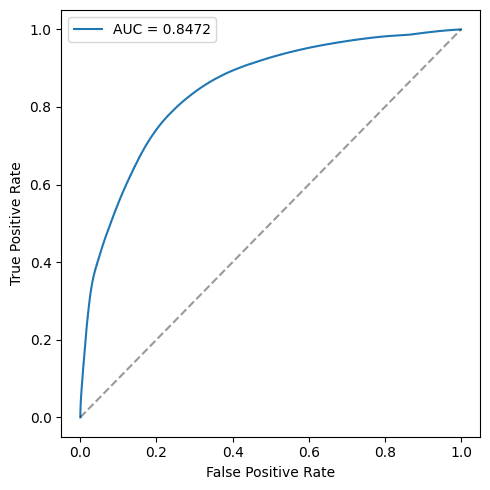

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(val_labels, val_scores)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(val_labels, val_scores):.4f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
#plt.savefig("roc_curve.png", dpi=150)

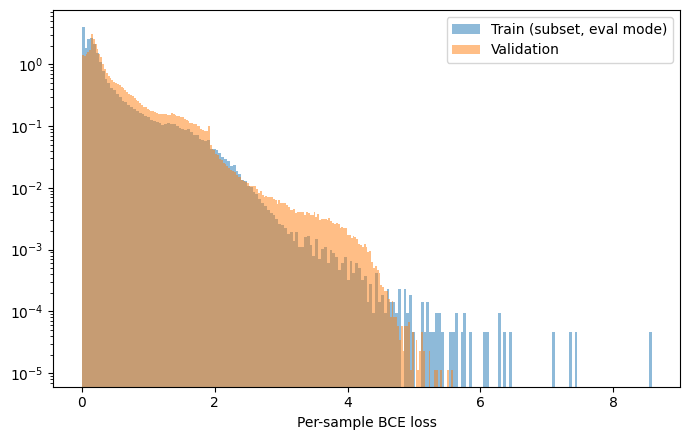

In [ ]:
# # Subset casuale del train (es. 500k jet, invece di tutti i 9.4M)
# rng = np.random.default_rng(RANDOM_SEED)
# idx = rng.choice(len(X_train), size=500_000, replace=False)

# train_subset_dataset = JetDataset(X_train[idx], y_train[idx])
# train_subset_loader = DataLoader(train_subset_dataset, batch_size=BATCH_SIZE, shuffle=False)

# train_labels_sub, train_scores_sub, train_logits_sub = get_predictions(
#     model_to_check, train_subset_loader, device=DEVICE
# )
# train_loss_sub = F.binary_cross_entropy_with_logits(
#     torch.from_numpy(train_logits_sub), torch.from_numpy(train_labels_sub), reduction="none"
# ).numpy()

# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.hist(train_loss_sub, bins=200, log=True, alpha=0.5, label="Train (subset, eval mode)", density=True)
# ax.hist(per_sample_loss, bins=200, log=True, alpha=0.5, label="Validation", density=True)
# ax.set_xlabel("Per-sample BCE loss")
# ax.legend()
# plt.tight_layout()
# #plt.savefig("train_vs_val_loss.png", dpi=150)

In [ ]:
thresholds = [0.5, 1.0, 2.0, 3.0, 5.0]
print(f"{'soglia':>8} | {'% train > soglia':>18} | {'% val > soglia':>16}")
for t in thresholds:
    frac_train = (per_sample_loss > t).mean() * 100
    frac_val   = (per_sample_loss_val > t).mean() * 100
    print(f"{t:8.1f} | {frac_train:18.4f} | {frac_val:16.4f}")

  soglia |   % train > soglia |   % val > soglia
     0.5 |            21.6018 |          31.1309
     1.0 |            10.6929 |          14.7553
     2.0 |             1.6752 |           1.8938
     3.0 |             0.1500 |           0.4221
     5.0 |             0.0050 |           0.0006
